# Dataset Exploring

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt


In [ ]:
# Set the path to the file you'd like to load
file_path = "commodity_trade_statistics_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "unitednations/global-commodity-trade-statistics",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/var/folders/pm/cnh4098x5cv02sy4zwlhygtc0000gn/T/ipykernel_3315/134323759.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 121M/121M [04:48<00:00, 438kB/s]  

Extracting zip of commodity_trade_statistics_data.csv...



/opt/anaconda3/envs/ada_exam_2024/lib/python3.10/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


First 5 records:   country_or_area  year comm_code  \
0     Afghanistan  2016     10410   
1     Afghanistan  2016     10420   
2     Afghanistan  2008     10210   
3         Albania  2016     10290   
4         Albania  2016     10392   

                                         commodity    flow  trade_usd  \
0                                      Sheep, live  Export       6088   
1                                      Goats, live  Export       3958   
2          Bovine animals, live pure-bred breeding  Import    1026804   
3  Bovine animals, live, except pure-bred breeding  Import    2414533   
4    Swine, live except pure-bred breeding > 50 kg  Import   14265937   

   weight_kg    quantity_name  quantity         category  
0     2339.0  Number of items      51.0  01_live_animals  
1      984.0  Number of items      53.0  01_live_animals  
2      272.0  Number of items    3769.0  01_live_animals  
3  1114023.0  Number of items    6853.0  01_live_animals  
4  9484953.0  Number of it

## Basic Dataset Overview

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.describe()

Shape: (8225871, 10)

Columns:
 Index(['country_or_area', 'year', 'comm_code', 'commodity', 'flow',
       'trade_usd', 'weight_kg', 'quantity_name', 'quantity', 'category'],
      dtype='object')


,year,trade_usd,weight_kg,quantity
count,8.225871e+06,8.225871e+06,8.097396e+06,7.921014e+06
mean,2.004768e+03,9.505370e+07,3.556503e+07,2.671470e+08
std,7.037779e+00,7.074154e+09,2.479277e+09,3.739231e+11
min,1.988000e+03,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.999000e+03,1.107200e+04,1.089000e+03,1.062000e+03
50%,2.005000e+03,1.534160e+05,2.689800e+04,2.712000e+04
75%,2.011000e+03,1.895476e+06,4.474432e+05,4.623620e+05
max,2.016000e+03,2.443311e+12,1.860133e+12,1.026357e+15


In [32]:
print("Years:", df["year"].min(), "-", df["year"].max())
print("Number of countries:", df["country_or_area"].nunique())
print("Number of categories:", df["category"].nunique())

Years: 1988 - 2016
Number of countries: 209
Number of categories: 98


## Missing values

In [33]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean()*100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

print(missing_df)

                 missing_count  missing_percent
quantity                304857         3.706076
weight_kg               128475         1.561841
country_or_area              0         0.000000
year                         0         0.000000
comm_code                    0         0.000000
commodity                    0         0.000000
flow                         0         0.000000
trade_usd                    0         0.000000
quantity_name                0         0.000000
category                     0         0.000000


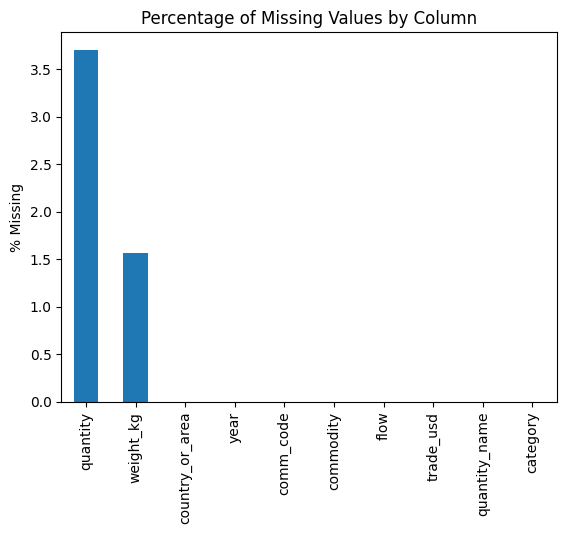

In [45]:
import matplotlib.pyplot as plt

missing_percent.plot(kind="bar")
plt.title("Percentage of Missing Values by Column")
plt.ylabel("% Missing")
plt.show()

The dataset is largely complete. Most variables have no missing values, while quantity has ~3.7% missing (304,857 rows) and weight_kg ~1.56% (128,475 rows). Since core variables (country, year, trade_flow, trade_usd) are fully populated, these gaps do not materially affect overall analysis. Analyses involving physical quantities may require filtering or imputation.

## Distribution of trave Values

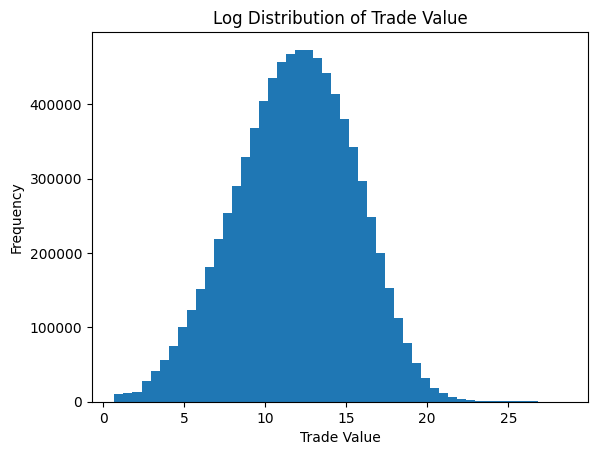

In [38]:
import numpy as np

plt.hist(np.log1p(df["trade_usd"]), bins=50)
plt.title("Log Distribution of Trade Value")
plt.xlabel("Trade Value")
plt.ylabel("Frequency")
plt.show()

Trade values (trade_usd) are highly skewed, with a few transactions accounting for very large volumes. A logarithmic transformation produces an approximately normal distribution, reflecting a wide range of transaction sizes from small trades to massive shipments.


## Weight VS Value comparison

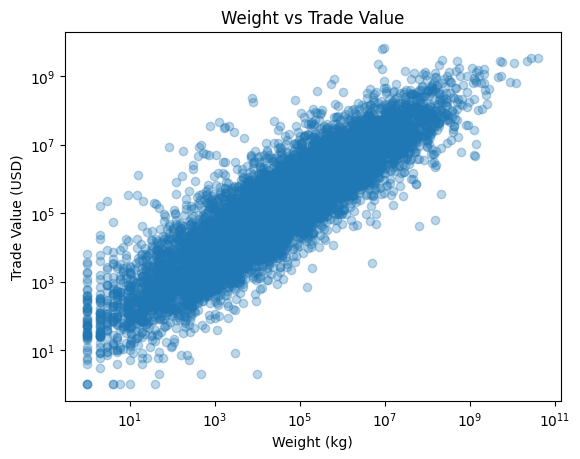

In [39]:
sample_df = df.sample(10000)

plt.scatter(sample_df["weight_kg"], sample_df["trade_usd"], alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Weight (kg)")
plt.ylabel("Trade Value (USD)")
plt.title("Weight vs Trade Value")
plt.show()

Log-log plots of weight_kg vs. trade_usd show a clear positive correlation: larger shipments generally correspond to higher values. Variation across commodities is evident—raw materials or agricultural goods often have high weight but low value, whereas electronics or pharmaceuticals are high-value but low-weight. This highlights structural differences between commodity categories in global trade.


## Trade evolution over time

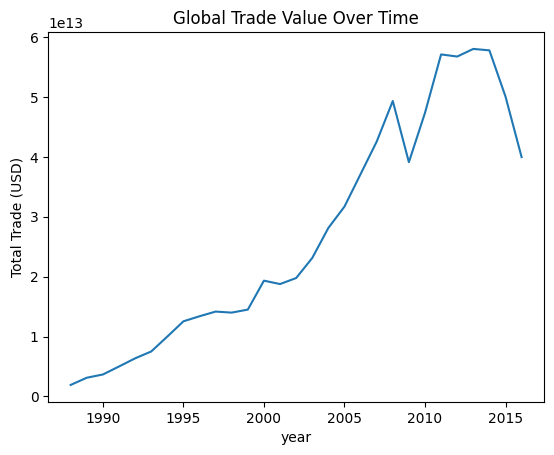

In [40]:
trade_year = df.groupby("year")["trade_usd"].sum()

trade_year.plot()
plt.title("Global Trade Value Over Time")
plt.ylabel("Total Trade (USD)")
plt.show()

## Top exporting Countries

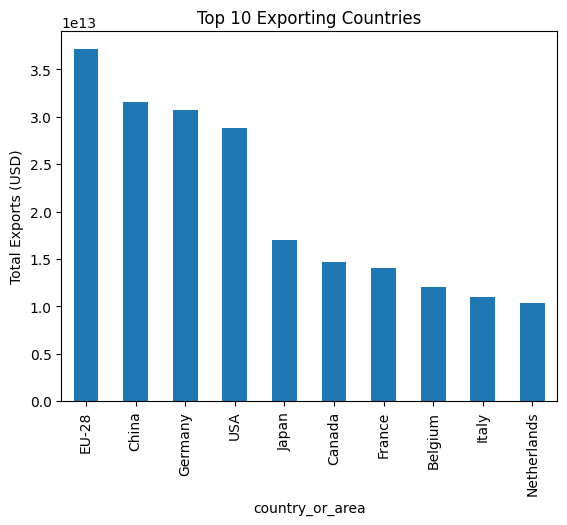

In [42]:
top_exporters = (
    df[df["flow"]=="Export"]
    .groupby("country_or_area")["trade_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_exporters.plot(kind="bar")
plt.title("Top 10 Exporting Countries")
plt.ylabel("Total Exports (USD)")
plt.show()

## China's export growth

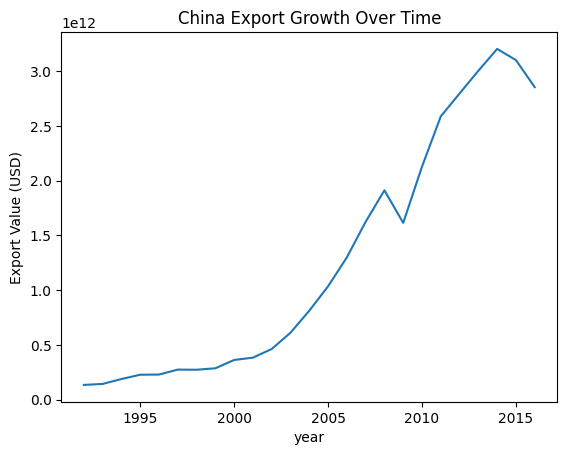

In [44]:
china = df[(df["country_or_area"]=="China") & (df["flow"]=="Export")]

china_trade = china.groupby("year")["trade_usd"].sum()

china_trade.plot()
plt.title("China Export Growth Over Time")
plt.ylabel("Export Value (USD)")
plt.show()

## Trade Value evolution over time by countries

In [9]:
# grouping of country and years
# aggregate country and year columns to get the total trade value for each country and year
grouped_df = df.groupby(['country_or_area', 'year'])['trade_usd'].sum().reset_index()
# then regroup by country to get the total trade value for each country
total_trade_by_country = grouped_df.groupby('country_or_area')['trade_usd'].sum().reset_index()
# sort the total trade value in descending order and get the top 10 countries
top_10_countries = total_trade_by_country.sort_values(by='trade_usd', ascending=False).head(10)
print("Top 10 countries by total trade value:")
print(top_10_countries)

Top 10 countries by total trade value:
          country_or_area       trade_usd
57                  EU-28  80560794323761
195                   USA  73323903319056
40                  China  61588304582650
76                Germany  58697172122513
98                  Japan  37162484244900
41   China, Hong Kong SAR  29814630422823
70                 France  29383423485551
35                 Canada  27624839749703
18                Belgium  23495688272767
199        United Kingdom  22941655426504


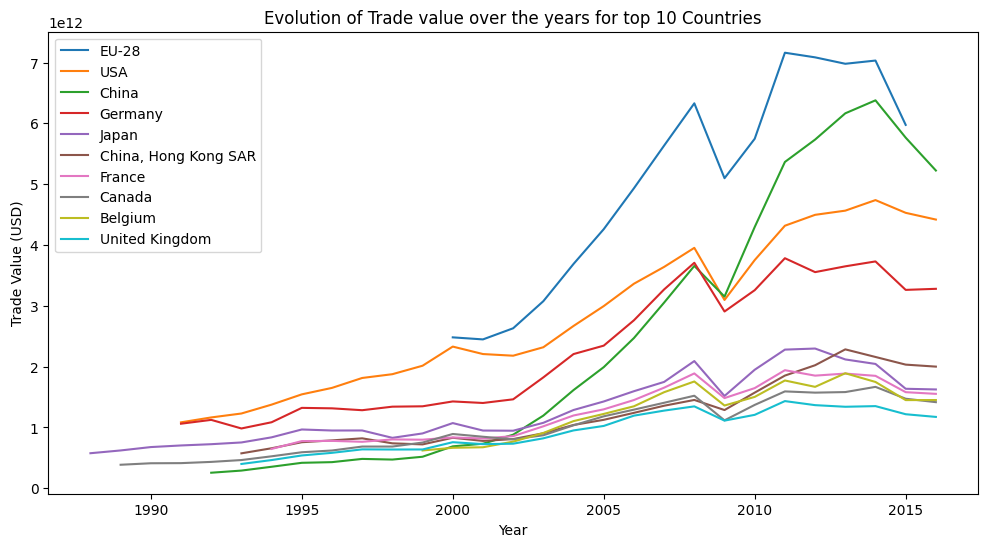

In [19]:
#chart of the grouped_df to see the evolution of trade value over the years for the top 10 countries
# filter the grouped_df to keep only the top 10 countries
filtered_grouped_df = grouped_df[grouped_df['country_or_area'].isin(top_10_countries['country_or_area'])]
# plot the evolution of trade value over the years for the top 10 countries
plt.figure(figsize=(12, 6))
for country in top_10_countries['country_or_area']:
    country_data = filtered_grouped_df[filtered_grouped_df['country_or_area'] == country]
    plt.plot(country_data['year'], country_data['trade_usd'], label=country)
plt.xlabel('Year')
plt.ylabel('Trade Value (USD)')
plt.title('Evolution of Trade value over the years for top 10 Countries')
plt.legend()
plt.show()  

In [12]:
grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3845 entries, 0 to 3844
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country_or_area  3845 non-null   object
 1   year             3845 non-null   int64 
 2   trade_usd        3845 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 90.2+ KB


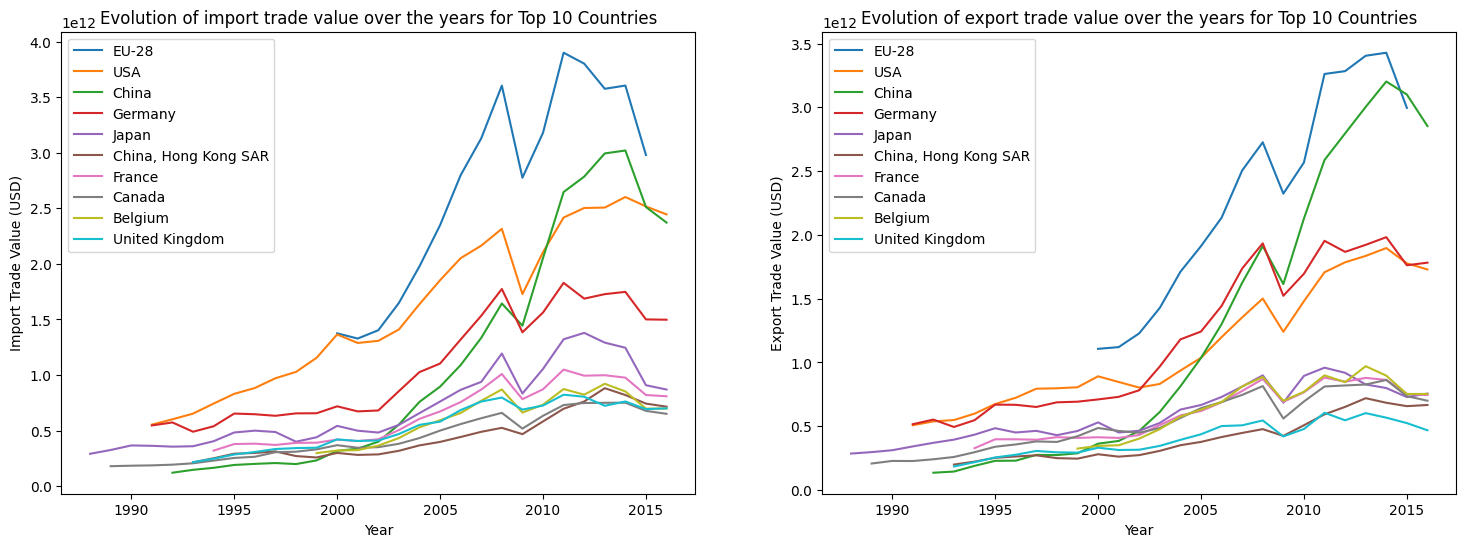

In [23]:
# 2 subcharts with Import or Export from the 'flow' column, there is no 'flow' column in the grouped_df, we need to go back to the original df and filter it by flow and then group it by country and year to get the total trade value for each country and year for Import and Export separately
# filter the original df by flow to get Import and Export dataframes
import_df = df[df['flow'] == 'Import']
export_df = df[df['flow'] == 'Export']
# group the Import and Export dataframes by country and year to get the total trade value for each country and year
grouped_import_df = import_df.groupby(['country_or_area', 'year'])['trade_usd'].sum().reset_index()
grouped_export_df = export_df.groupby(['country_or_area', 'year'])['trade_usd'].sum().reset_index()
# filter the grouped Import and Export dataframes to keep only the top 10 countries
filtered_grouped_import_df = grouped_import_df[grouped_import_df['country_or_area'].isin(top_10_countries['country_or_area'])]
filtered_grouped_export_df = grouped_export_df[grouped_export_df['country_or_area'].isin(top_10_countries['country_or_area'])]
# plot the evolution of trade value over the years for the top 10 countries for Import and Export separately
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for country in top_10_countries['country_or_area']:
    country_import_data = filtered_grouped_import_df[filtered_grouped_import_df['country_or_area'] == country]
    country_export_data = filtered_grouped_export_df[filtered_grouped_export_df['country_or_area'] == country]
    axes[0].plot(country_import_data['year'], country_import_data['trade_usd'], label=country)
    axes[1].plot(country_export_data['year'], country_export_data['trade_usd'], label=country)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Import Trade Value (USD)')
# axes[0].set_ylim(0, 4)
axes[0].set_title('Evolution of import trade value over the years for Top 10 Countries')
axes[0].legend()
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Export Trade Value (USD)')
# axes[1].set_ylim(0, 4)
axes[1].set_title('Evolution of export trade value over the years for Top 10 Countries')
axes[1].legend()
plt.show()  

Time-series plots for the top ten trading economies show strong growth from the early 1990s to mid-2010s. The EU-28 and the United States consistently dominate, while China exhibits rapid export growth from the early 2000s, reflecting its integration into global supply chains.

# Distribution of commodity Categories

In [22]:
list(df['category'].unique())

['01_live_animals',
 '02_meat_and_edible_meat_offal',
 '03_fish_crustaceans_molluscs_aquatic_invertebrates_ne',
 '04_dairy_products_eggs_honey_edible_animal_product_nes',
 '05_products_of_animal_origin_nes',
 '06_live_trees_plants_bulbs_roots_cut_flowers_etc',
 '07_edible_vegetables_and_certain_roots_and_tubers',
 '08_edible_fruit_nuts_peel_of_citrus_fruit_melons',
 '09_coffee_tea_mate_and_spices',
 '10_cereals',
 '11_milling_products_malt_starches_inulin_wheat_glute',
 '12_oil_seed_oleagic_fruits_grain_seed_fruit_etc_ne',
 '13_lac_gums_resins_vegetable_saps_and_extracts_nes',
 '14_vegetable_plaiting_materials_vegetable_products_nes',
 '15_animal_vegetable_fats_and_oils_cleavage_products_et',
 '16_meat_fish_and_seafood_food_preparations_nes',
 '17_sugars_and_sugar_confectionery',
 '18_cocoa_and_cocoa_preparations',
 '19_cereal_flour_starch_milk_preparations_and_products',
 '20_vegetable_fruit_nut_etc_food_preparations',
 '21_miscellaneous_edible_preparations',
 '22_beverages_spirits_an

In [21]:
df['category'].value_counts()

category
95_toys_games_sports_requisites                           100000
54_manmade_filaments                                      100000
62_articles_of_apparel_accessories_not_knit_or_crochet    100000
61_articles_of_apparel_accessories_knit_or_crochet        100000
59_impregnated_coated_or_laminated_textile_fabric         100000
                                                           ...  
45_cork_and_articles_of_cork                               31446
14_vegetable_plaiting_materials_vegetable_products_nes     30179
80_tin_and_articles_thereof                                29328
all_commodities                                             9185
99_commodities_not_specified_according_to_kind              7024
Name: count, Length: 98, dtype: int64

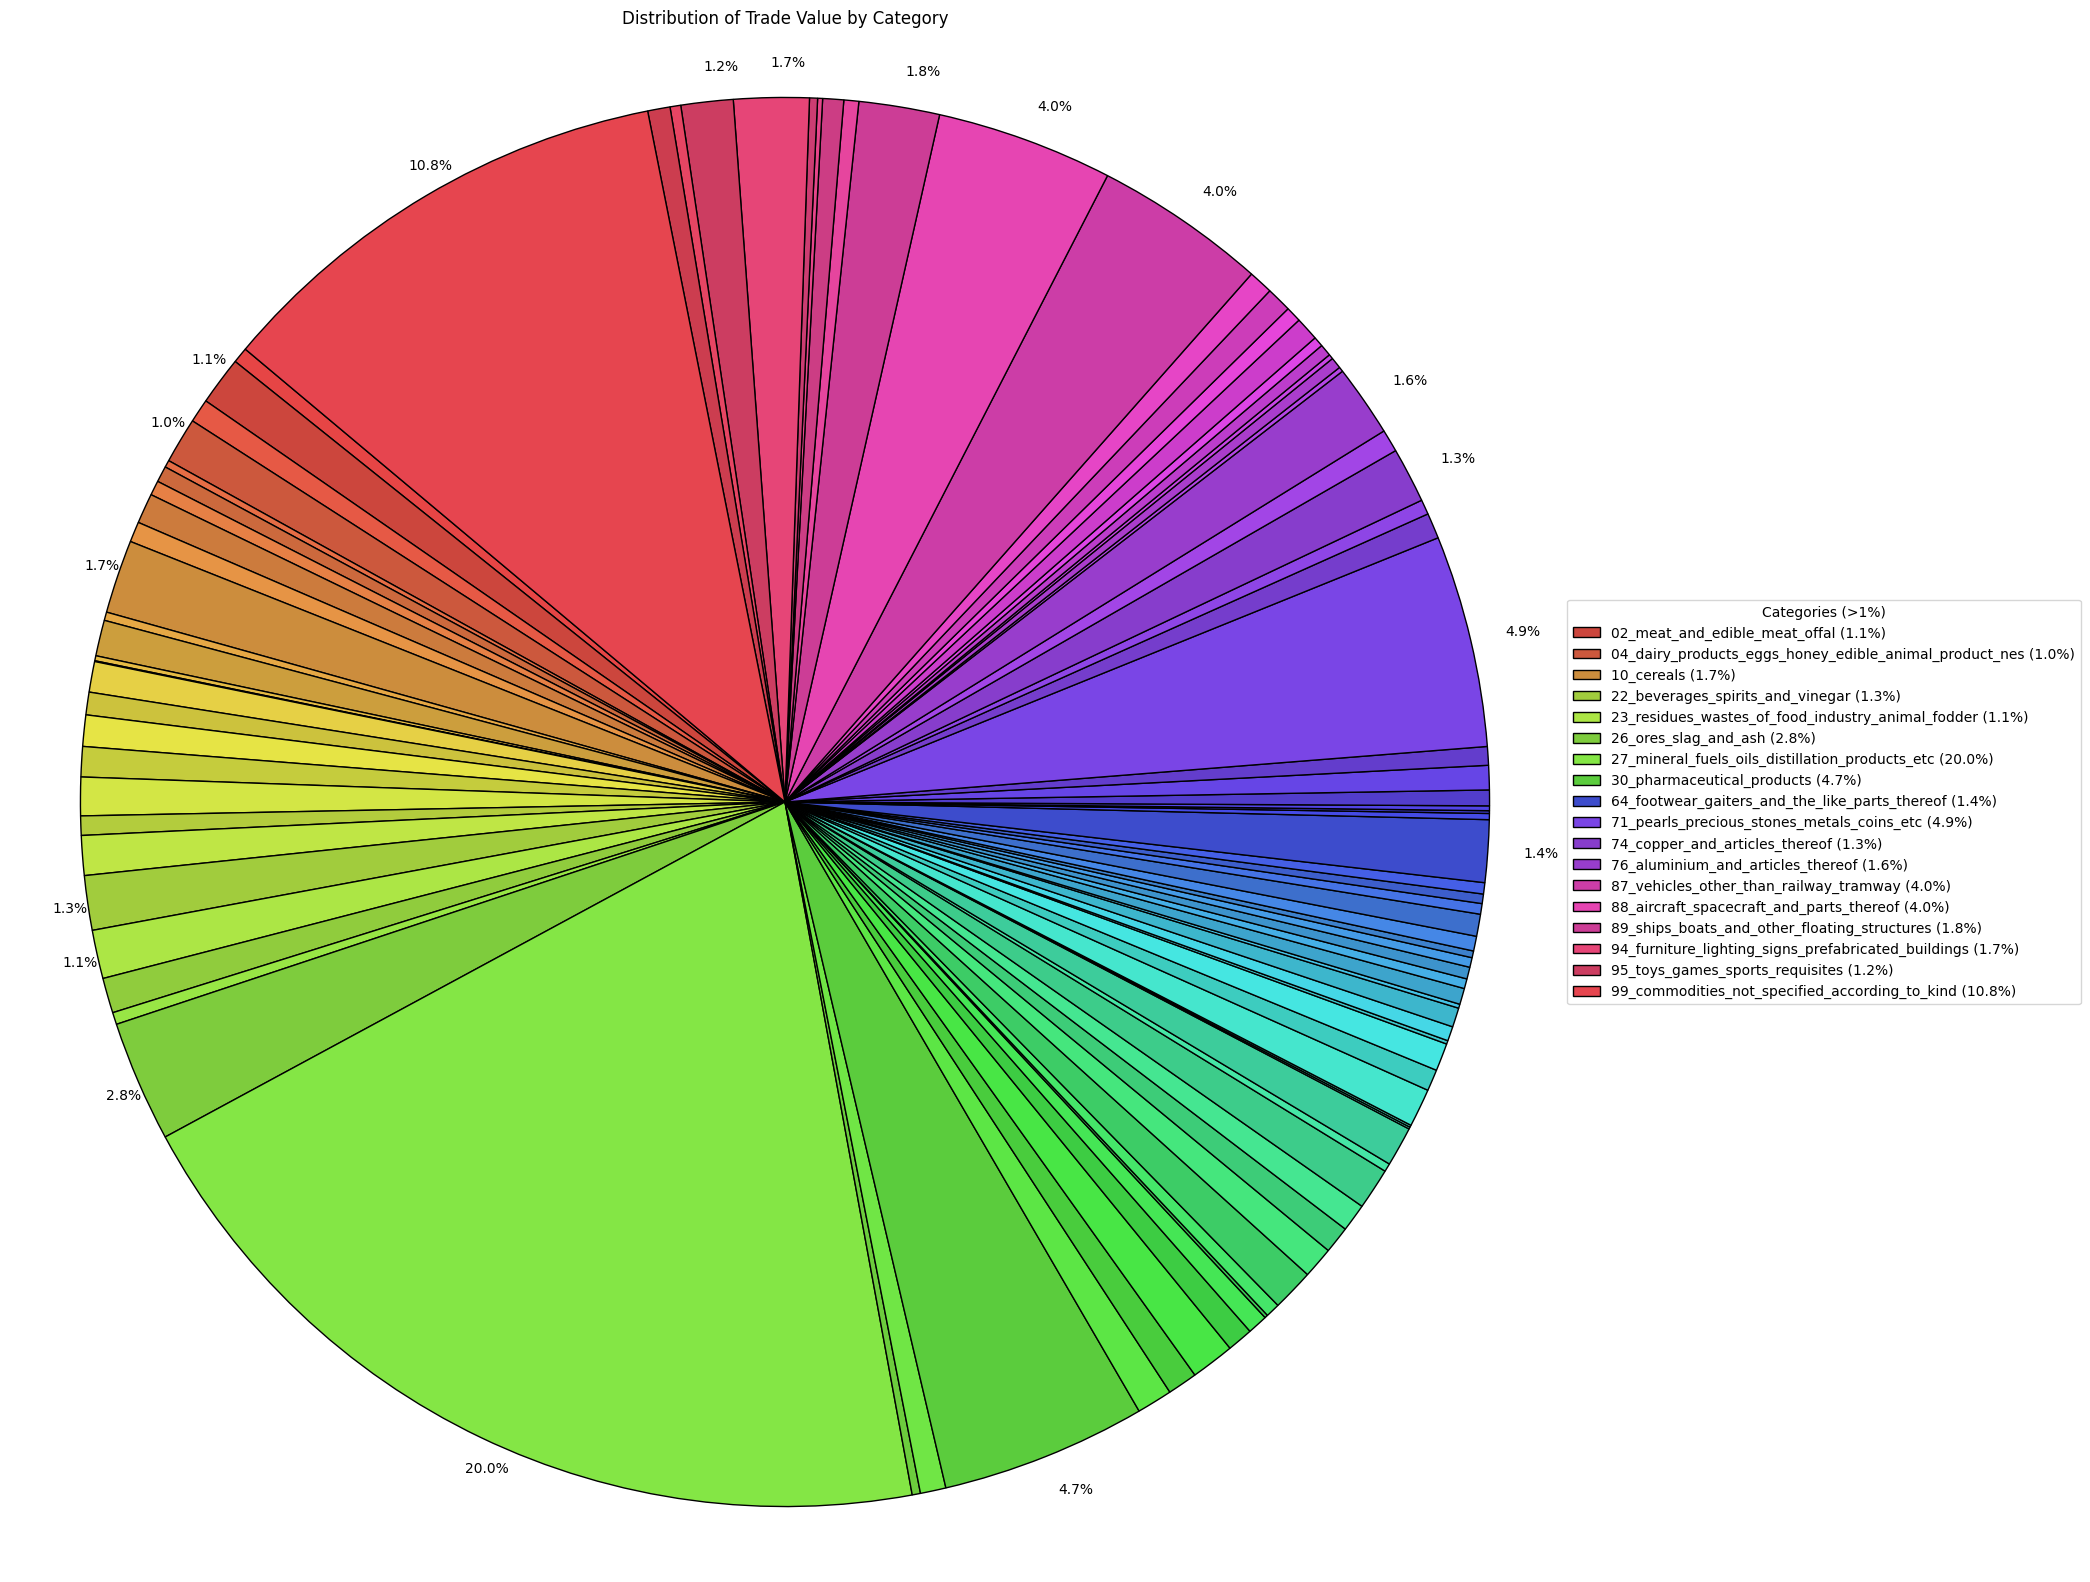

In [94]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# remove 'all_commodities'
filtered_df = df[df['category'] != 'all_commodities']

# group by category
category_trade = filtered_df.groupby('category')['trade_usd'].sum().reset_index()
num_categories = len(category_trade)

# generate colors: alternating brightness for more distinction
hues = np.linspace(0, 1, num_categories, endpoint=False)
sat = 0.7
colors = [mcolors.hsv_to_rgb((h, sat, 0.9 if i % 2 == 0 else 0.8)) for i, h in enumerate(hues)]
colors = [mcolors.to_hex(c) for c in colors]

# compute percentages
total_trade = category_trade['trade_usd'].sum()
category_trade['pct'] = category_trade['trade_usd'] / total_trade * 100

# plot pie
fig, ax = plt.subplots(figsize=(20, 20))

wedges, texts, autotexts = ax.pie(
    category_trade['trade_usd'],
    startangle=140,
    colors=colors,
    labels=None,        # no labels on slices
    autopct=lambda pct: f'{pct:.1f}%' if pct > 1 else '',  # hide tiny percentages inside
    pctdistance=1.05,   # push percentage outside the slices
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}  # black borders
)

# move percentages further out for clarity
for autotext in autotexts:
    autotext.set_horizontalalignment('left')
    autotext.set_fontsize(10)

# create legend for only categories with pct > 1
legend_wedges = [w for w, pct in zip(wedges, category_trade['pct']) if pct > 1]
legend_labels = [
    f"{cat} ({pct:.1f}%)" 
    for cat, pct in zip(category_trade['category'], category_trade['pct']) 
    if pct > 1
]

ax.legend(
    legend_wedges,
    legend_labels,
    title="Categories (>1%)",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

ax.set_title('Distribution of Trade Value by Category')
ax.axis('equal')
plt.show()

The top categories by trade value are: mineral fuels, oils, and distillation products (20%), commodities not specified according to kind (10.8%), pearls, precious stones, metals, and coins (4.9%), pharmaceutical products (4.7%), aircraft, spacecraft, and parts thereof (4%), and vehicles other than railway/tramway (4%). Further exploration will focus on the composition of commodities not specified according to kind.